In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
x_train = x_train[..., np.newaxis] # új dimenzió létrehozása
x_test = x_test[..., np.newaxis]

print(x_train.shape)  # (60000, 28, 28, 1)

(60000, 28, 28, 1)


In [5]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)), # szűrő létrehozása
    layers.MaxPooling2D((2,2)), # csak a lényegi részt tartja meg

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8277 - loss: 0.4782 - val_accuracy: 0.8693 - val_loss: 0.3577
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8829 - loss: 0.3211 - val_accuracy: 0.8898 - val_loss: 0.3046
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8996 - loss: 0.2759 - val_accuracy: 0.8935 - val_loss: 0.2814
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9088 - loss: 0.2476 - val_accuracy: 0.9048 - val_loss: 0.2746
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9170 - loss: 0.2236 - val_accuracy: 0.9087 - val_loss: 0.2559


In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Teszt pontosság:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9008 - loss: 0.2654
Teszt pontosság: 0.9007999897003174


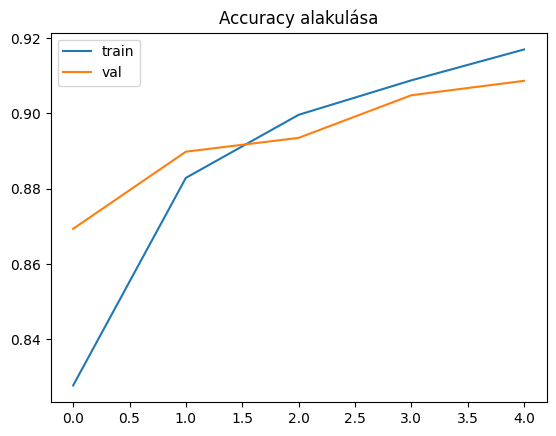

In [9]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy alakulása")
plt.show()

In [10]:
pred = model.predict(x_test[:1])

print("Valós címke:", y_test[0])
print("Predikció:", np.argmax(pred))
print("Valószínűségek:", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Valós címke: 9
Predikció: 9
Valószínűségek: [[3.6676934e-06 2.6252610e-07 6.9541670e-06 9.8163935e-07 4.6707974e-06
  9.8138803e-04 5.0260934e-07 5.6092059e-03 4.8031550e-05 9.9334431e-01]]
